# Compare summary data for all scenarios

In [1]:
import calendar
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl
import re

# Functions

In [2]:
def season_of_date(date_UTC):
    """Returns season for given datetime"""
    year = str(pd.to_datetime(date_UTC.strftime('%Y-%m-%d')).year)
    seasons = {'spring': pd.date_range(start= pd.to_datetime(year +'-03-21'), end=pd.to_datetime(year + '-06-20')),
               'summer': pd.date_range(start= pd.to_datetime(year + '-06-21'), end= pd.to_datetime(year + '-09-22')),
               'autumn': pd.date_range(start= pd.to_datetime(year + '-09-23'), end= pd.to_datetime(year + '-12-20')),
               'winter': pd.date_range(start= pd.to_datetime(year + '-12-21'), end= pd.to_datetime(year + '-03-20'))}
    if (pd.to_datetime(year +'-03-21') <= date_UTC <= pd.to_datetime(year + '-06-20')):
        return 'spring'
    elif (pd.to_datetime(year +'-06-21') <= date_UTC <= pd.to_datetime(year + '-09-22')):
        return 'summer'
    elif (pd.to_datetime(year +'-09-23') <= date_UTC <= pd.to_datetime(year + '-12-20')):
        return 'autumn'
    else:
        return 'winter'

# PEA

In [3]:
path_figures = 'C:/Users/midauarg/OneDrive - Lancaster University/PhD/Modelling - Lake CAB/results/figures_FPV/FPV_scenarios/PEA/'

In [6]:
PEA_df = pd.read_csv('PEA_df_01_02.csv')
PEA_df['time'] = pd.to_datetime(PEA_df['time'])
PEA_df.set_index('time', inplace = True)
PEA_df.head(2)

,41% FPV - 10% gaps 80x80m,43% FPV - 5% gaps 10x10m,41% FPV - 10% gaps 10x10m,41% FPV - 10% gaps 10x20m,41% FPV - 10% gaps 20x20m,37% FPV - 20% gaps 10x10m,37% without gaps,41% without gaps,43% without gaps,46% without gaps,No FPV coverage
time,,,,,,,,,,,
2022-09-09 00:00:00,1061.838514,1061.838514,1061.838514,1061.838514,1061.838514,1061.838514,1061.838514,1061.838514,1061.838514,1061.838514,1061.838514
2022-09-09 06:00:00,420.903165,420.836784,421.479538,422.698376,421.024502,421.664445,419.762463,420.530689,420.863233,423.417262,417.113113


In [7]:
## DATAFRAME FOR CREATING BOXPLOTS - depth averaged water temperature
scenarios = list(PEA_df.columns)

for scen in range(len(scenarios)):
    temp_PEA = pd.DataFrame((PEA_df[scenarios[scen]]/1000).copy())
    temp_PEA.rename(columns = {temp_PEA.columns[0]:'PEA'}, inplace = True)
    temp_PEA['scenario'] = scenarios[scen]
    # Join result to dataframe with control run output for comparison
    if scen == 0:
        bp_PEA_wholelake_comp = temp_PEA.copy()
    else:
        bp_PEA_wholelake_comp = pd.concat([bp_PEA_wholelake_comp, temp_PEA])

# Creates columns with month
bp_PEA_wholelake_comp['month'] = bp_PEA_wholelake_comp.index.month
bp_PEA_wholelake_comp['year'] = bp_PEA_wholelake_comp.index.year
bp_PEA_wholelake_comp['year'] = bp_PEA_wholelake_comp['year'].apply(lambda x: str(x)[2:])
bp_PEA_wholelake_comp['month_str'] = ((bp_PEA_wholelake_comp['month'].apply(lambda x: calendar.month_abbr[x])) + 
                                      (bp_PEA_wholelake_comp['year']))
bp_PEA_wholelake_comp.reset_index(drop = False, inplace = True)
bp_PEA_wholelake_comp['season'] = bp_PEA_wholelake_comp['time'].apply(season_of_date)
bp_PEA_wholelake_comp.head(2)

,time,PEA,scenario,month,year,month_str,season
0,2022-09-09 00:00:00,1.061839,41% FPV - 10% gaps 80x80m,9,22,Sep22,summer
1,2022-09-09 06:00:00,0.420903,41% FPV - 10% gaps 80x80m,9,22,Sep22,summer


In [8]:
scenarios

['41% FPV - 10% gaps 80x80m',
 '43% FPV - 5% gaps 10x10m',
 '41% FPV - 10% gaps 10x10m',
 '41% FPV - 10% gaps 10x20m',
 '41% FPV - 10% gaps 20x20m',
 '37% FPV - 20% gaps 10x10m',
 '37% without gaps',
 '41% without gaps',
 '43% without gaps',
 '46% without gaps',
 'No FPV coverage']

<ipython-input-11-0014d776deb1>:22: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(xlabels_new)


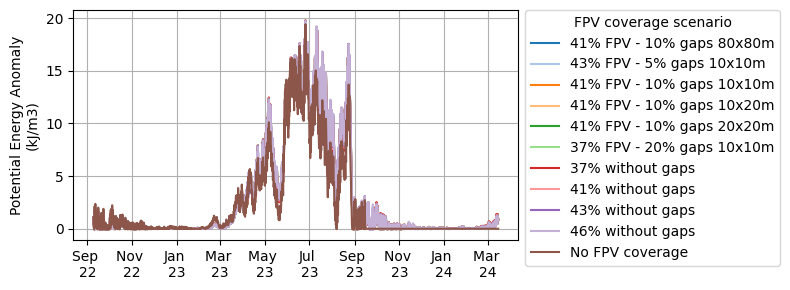

In [11]:
# Plot time series raw data for WT among scenarios
fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize = [8,3], sharex = True, sharey = True)
pal = sns.color_palette("tab20", 15)

scenarios = list(PEA_df.columns)

# scenarios = ['46% FPV - no gaps', '43% FPV - no gaps', '41% FPV - no gaps', '37% FPV - no gaps', 
#             '43% FPV - 5% gaps 10x10m', '41% FPV - 10% gaps 10x10m', '37% FPV - 20% gaps 10x10m', 
#             '41% FPV - 10% gaps 10x10m', '41% FPV - 10% gaps 10x20m', '41% FPV - 10% gaps 20x20m', '41% FPV - 10% gaps 80x80m']


for scen in range(len(scenarios)):
    temp = pd.DataFrame((PEA_df[PEA_df.columns[scen]]/1000).copy())

    ax.plot(temp.index, temp[temp.columns[-1]], color = pal.as_hex()[scen], linestyle='-', 
            label = (PEA_df.columns[scen]))

ax.grid(True)

xlabels = ['Sep 22', 'Nov 22', 'Jan 23', 'Mar 23', 'May 23', 'Jul 23', 'Sep 23', 'Nov 23', 'Jan 24', 'Mar 24']
xlabels_new = [re.sub("(.{4})", "\\1\n", label, 0, re.DOTALL) for label in xlabels]
ax.set_xticklabels(xlabels_new)

ax.legend(title = "FPV coverage scenario", ncol = 1, fontsize = 10, frameon = True, columnspacing = 1,
          bbox_to_anchor=(1, 1.03))

ax.yaxis.set_label_text(u'Potential Energy Anomaly\n(kJ/m3)')
# ax.yaxis.set_major_formatter(mpl.ticker.StrMethodFormatter('{x:,.0f}'))

plt.subplots_adjust(wspace = 0, hspace = 0)

plt.tight_layout() # Para ajustar melhor os gráficos
plt.rcdefaults()
# plt.savefig(path_figures + 'FPVall_wholelake_PEA_timeseries.jpeg', dpi = 300, bbox_inches='tight')

plt.show();

In [12]:
bp_PEA_wholelake_comp.scenario.unique()

array(['41% FPV - 10% gaps 80x80m', '43% FPV - 5% gaps 10x10m',
       '41% FPV - 10% gaps 10x10m', '41% FPV - 10% gaps 10x20m',
       '41% FPV - 10% gaps 20x20m', '37% FPV - 20% gaps 10x10m',
       '37% without gaps', '41% without gaps', '43% without gaps',
       '46% without gaps', 'No FPV coverage'], dtype=object)

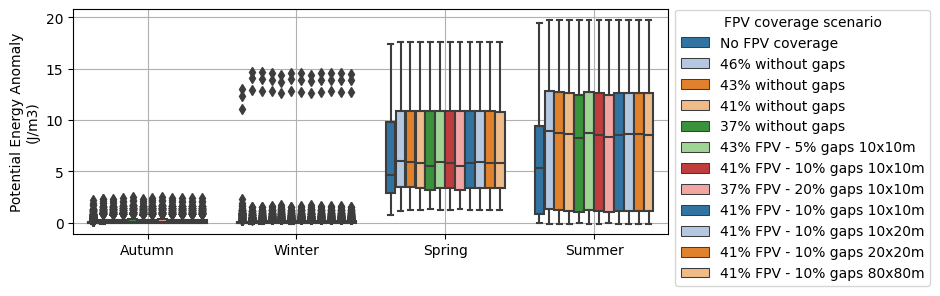

In [14]:
# Plot time series raw data for WT among scenarios
fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize = [9.5,3], sharex = True, sharey = True)
pal = sns.color_palette("tab20", 20)

# my_order = ['41% FPV - 80x80m', '41% FPV - 10x10m', '41% FPV - 10x20m', '41% FPV - 20x20m']

my_order = ['No FPV coverage', '46% without gaps', '43% without gaps', '41% without gaps', '37% without gaps', 
            '43% FPV - 5% gaps 10x10m', '41% FPV - 10% gaps 10x10m', '37% FPV - 20% gaps 10x10m', 
            '41% FPV - 10% gaps 10x10m', '41% FPV - 10% gaps 10x20m', '41% FPV - 10% gaps 20x20m', 
            '41% FPV - 10% gaps 80x80m']

sns.boxplot(x = "season", y = "PEA", 
            data = bp_PEA_wholelake_comp,
            width = 0.8, boxprops = {'zorder': 2}, palette = pal[0:8], ax = ax, 
            order = ['autumn', 'winter', 'spring', 'summer'],
            hue = 'scenario', hue_order = my_order)

ax.grid(True)

# ax.legend(title = "FPV coverage scenario", ncol = 1, fontsize = 10, 
#                frameon = True, columnspacing = 1)

ax.legend(title = "FPV coverage scenario", ncol = 1, fontsize = 10, 
               frameon = True, columnspacing = 1, bbox_to_anchor=(1, 1.03))

ax.yaxis.set_label_text(u'Potential Energy Anomaly\n(J/m3)', fontsize = 10)
ax.xaxis.set_label_text(u'', fontsize = 10)

ax.set_xticklabels(['Autumn', 'Winter', 'Spring', 'Summer'], fontsize=10)

ax.yaxis.set_major_formatter(mpl.ticker.StrMethodFormatter('{x:,.0f}'))

plt.subplots_adjust(wspace = 0, hspace = 0)

plt.tight_layout() # Para ajustar melhor os gráficos
plt.rcdefaults()
# plt.savefig(path_figures + 'FPVall_wholelake_PEA_boxplot_seasonal.jpeg', dpi=600, bbox_inches='tight')

plt.show();

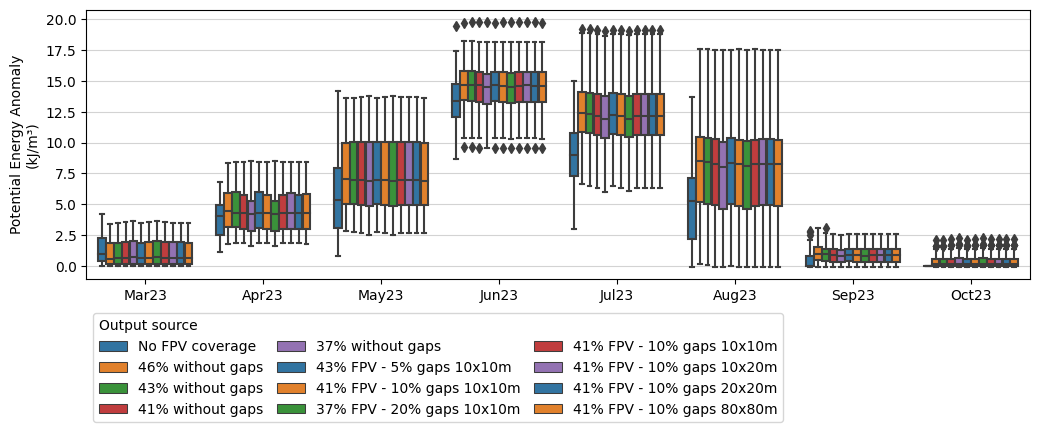

In [16]:
# Plot graph with delta between scenarios and control run
fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize = [10.5,4.5], sharey = True)

pal = sns.color_palette("tab10",5)

plot = bp_PEA_wholelake_comp[(bp_PEA_wholelake_comp['month_str'] == 'Mar23') | 
                             (bp_PEA_wholelake_comp['month_str'] == 'Apr23') | 
                             (bp_PEA_wholelake_comp['month_str'] == 'May23') | 
                             (bp_PEA_wholelake_comp['month_str'] == 'Jun23') | 
                             (bp_PEA_wholelake_comp['month_str'] == 'Jul23') | 
                             (bp_PEA_wholelake_comp['month_str'] == 'Aug23') | 
                             (bp_PEA_wholelake_comp['month_str'] == 'Sep23') | 
                             (bp_PEA_wholelake_comp['month_str'] == 'Oct23')]

my_order = ['No FPV coverage', '46% without gaps', '43% without gaps', '41% without gaps', '37% without gaps', 
            '43% FPV - 5% gaps 10x10m', '41% FPV - 10% gaps 10x10m', '37% FPV - 20% gaps 10x10m', 
            '41% FPV - 10% gaps 10x10m', '41% FPV - 10% gaps 10x20m', '41% FPV - 10% gaps 20x20m', 
            '41% FPV - 10% gaps 80x80m']

# CAB location
sns.boxplot(x = "month_str", y = "PEA", data = plot,
            width = 0.8, boxprops = {'zorder': 1}, palette = pal[0:6], ax = ax, hue = 'scenario', hue_order = my_order)

# ax.set_xticks([0,1,2,3,4,5,6,7,8,9,10,11],
#               ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'],
#               fontsize = 10)

ax.tick_params(axis = 'y', which = 'major', labelsize = 10)
ax.yaxis.set_label_text(u'Potential Energy Anomaly\n(kJ/m³)', fontsize = 10)
ax.xaxis.set_label_text(u'', fontsize = 10)

ax.legend(title = "Output source", loc="upper left", ncol = 3, fontsize = 10, 
          frameon = True, columnspacing = 1, bbox_to_anchor=(0, -0.1))._legend_box.align = "left"

ax.set_axisbelow(True)
ax.grid(color='lightgray', axis = 'y')

plt.subplots_adjust(wspace=0, hspace=0)

plt.tight_layout() # Para ajustar melhor os gráficos
plt.rcdefaults()
# plt.savefig('FPVall_wholelake_PEA_boxplot_monthly.jpeg', dpi = 300, bbox_inches='tight')

plt.show();

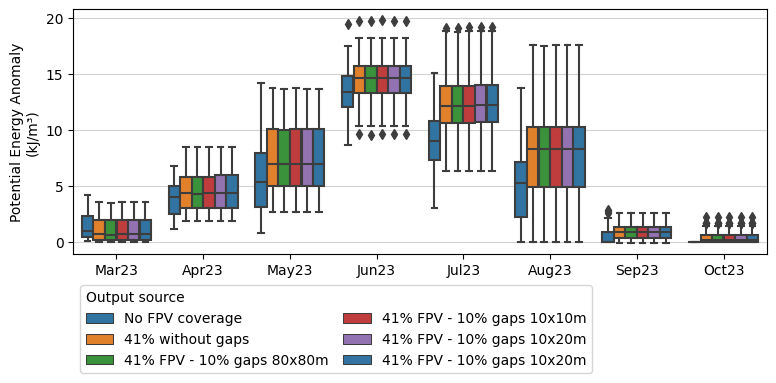

In [18]:
# Plot graph with delta between scenarios and control run
fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize = [8,4], sharey = True)

pal = sns.color_palette("tab10",5)

plot = bp_PEA_wholelake_comp[(bp_PEA_wholelake_comp['month_str'] == 'Mar23') | 
                             (bp_PEA_wholelake_comp['month_str'] == 'Apr23') | 
                             (bp_PEA_wholelake_comp['month_str'] == 'May23') | 
                             (bp_PEA_wholelake_comp['month_str'] == 'Jun23') | 
                             (bp_PEA_wholelake_comp['month_str'] == 'Jul23') | 
                             (bp_PEA_wholelake_comp['month_str'] == 'Aug23') | 
                             (bp_PEA_wholelake_comp['month_str'] == 'Sep23') | 
                             (bp_PEA_wholelake_comp['month_str'] == 'Oct23')]

plot = plot[(plot['scenario'] == 'No FPV coverage') |
            (plot['scenario'] == '41% without gaps') | 
            (plot['scenario'] == '41% FPV - 10% gaps 80x80m') | 
            (plot['scenario'] == '41% FPV - 10% gaps 10x10m') | 
            (plot['scenario'] == '41% FPV - 10% gaps 10x20m') | 
            (plot['scenario'] == '41% FPV - 10% gaps 10x20m')]

my_order = ['No FPV coverage', '41% without gaps', '41% FPV - 10% gaps 80x80m', '41% FPV - 10% gaps 10x10m',
           '41% FPV - 10% gaps 10x20m', '41% FPV - 10% gaps 10x20m']

# my_order = ['No FPV coverage', '46% without gaps', '43% without gaps', '41% without gaps', '37% without gaps', 
#             '43% FPV - 5% gaps 10x10m', '41% FPV - 10% gaps 10x10m', '37% FPV - 20% gaps 10x10m', 
#             '41% FPV - 10% gaps 10x10m', '41% FPV - 10% gaps 10x20m', '41% FPV - 10% gaps 20x20m', 
#             '41% FPV - 10% gaps 80x80m']

# CAB location
sns.boxplot(x = "month_str", y = "PEA", data = plot,
            width = 0.8, boxprops = {'zorder': 1}, palette = pal[0:6], ax = ax, hue = 'scenario', hue_order = my_order)

# ax.set_xticks([0,1,2,3,4,5,6,7,8,9,10,11],
#               ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'],
#               fontsize = 10)

ax.tick_params(axis = 'y', which = 'major', labelsize = 10)
ax.yaxis.set_label_text(u'Potential Energy Anomaly\n(kJ/m³)', fontsize = 10)
ax.xaxis.set_label_text(u'', fontsize = 10)

ax.legend(title = "Output source", loc="upper left", ncol = 2, fontsize = 10, 
          frameon = True, columnspacing = 1, bbox_to_anchor=(0, -0.1))._legend_box.align = "left"

ax.set_axisbelow(True)
ax.grid(color='lightgray', axis = 'y')

plt.subplots_adjust(wspace=0, hspace=0)

plt.tight_layout() # Para ajustar melhor os gráficos
plt.rcdefaults()
# plt.savefig('FPV03_wholelake_PEA_boxplot_monthly.jpeg', dpi = 300, bbox_inches='tight')

plt.show();

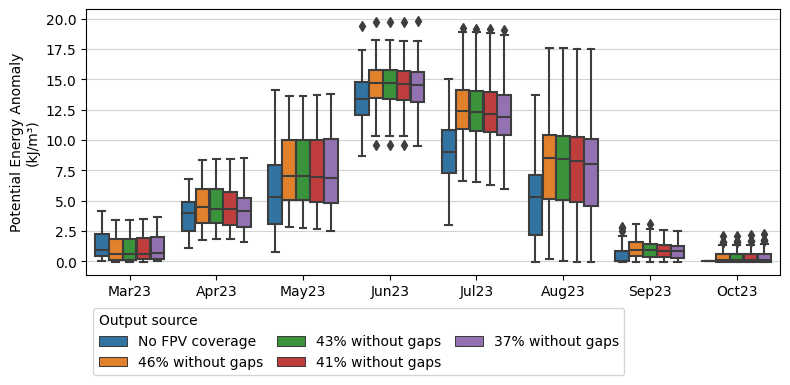

In [20]:
# Plot graph with delta between scenarios and control run
fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize = [8,4], sharey = True)

pal = sns.color_palette("tab10",5)

plot = bp_PEA_wholelake_comp[(bp_PEA_wholelake_comp['month_str'] == 'Mar23') | 
                             (bp_PEA_wholelake_comp['month_str'] == 'Apr23') | 
                             (bp_PEA_wholelake_comp['month_str'] == 'May23') | 
                             (bp_PEA_wholelake_comp['month_str'] == 'Jun23') | 
                             (bp_PEA_wholelake_comp['month_str'] == 'Jul23') | 
                             (bp_PEA_wholelake_comp['month_str'] == 'Aug23') | 
                             (bp_PEA_wholelake_comp['month_str'] == 'Sep23') | 
                             (bp_PEA_wholelake_comp['month_str'] == 'Oct23')]

plot = plot[(plot['scenario'] == 'No FPV coverage') |
            (plot['scenario'] == '46% without gaps') | 
            (plot['scenario'] == '43% without gaps') | 
            (plot['scenario'] == '41% without gaps') | 
            (plot['scenario'] == '37% without gaps')]

my_order = ['No FPV coverage', '46% without gaps', '43% without gaps', '41% without gaps', '37% without gaps']

# my_order = ['No FPV coverage', '46% without gaps', '43% without gaps', '41% without gaps', '37% without gaps', 
#             '43% FPV - 5% gaps 10x10m', '41% FPV - 10% gaps 10x10m', '37% FPV - 20% gaps 10x10m', 
#             '41% FPV - 10% gaps 10x10m', '41% FPV - 10% gaps 10x20m', '41% FPV - 10% gaps 20x20m', 
#             '41% FPV - 10% gaps 80x80m']

# CAB location
sns.boxplot(x = "month_str", y = "PEA", data = plot,
            width = 0.8, boxprops = {'zorder': 1}, palette = pal[0:6], ax = ax, hue = 'scenario', hue_order = my_order)

# ax.set_xticks([0,1,2,3,4,5,6,7,8,9,10,11],
#               ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'],
#               fontsize = 10)

ax.tick_params(axis = 'y', which = 'major', labelsize = 10)
ax.yaxis.set_label_text(u'Potential Energy Anomaly\n(kJ/m³)', fontsize = 10)
ax.xaxis.set_label_text(u'', fontsize = 10)

ax.legend(title = "Output source", loc="upper left", ncol = 3, fontsize = 10, 
          frameon = True, columnspacing = 1, bbox_to_anchor=(0, -0.1))._legend_box.align = "left"

ax.set_axisbelow(True)
ax.grid(color='lightgray', axis = 'y')

plt.subplots_adjust(wspace=0, hspace=0)

plt.tight_layout() # Para ajustar melhor os gráficos
plt.rcdefaults()
# plt.savefig('FPV01_wholelake_PEA_boxplot_monthly.jpeg', dpi = 300, bbox_inches='tight')

plt.show();

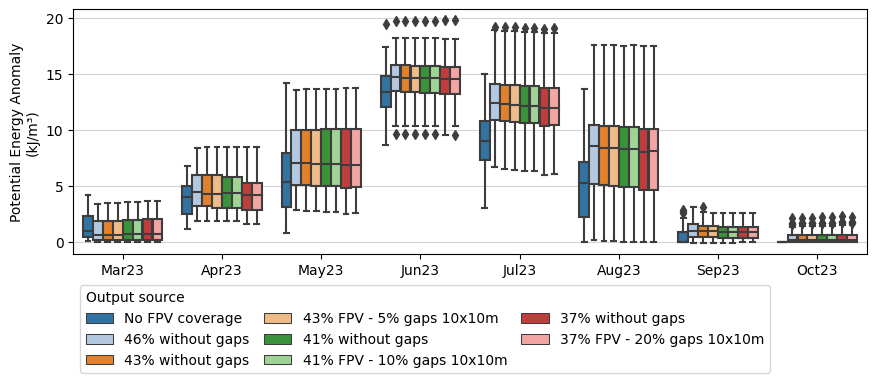

In [22]:
# Plot graph with delta between scenarios and control run
fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize = [9,4], sharey = True)

pal = sns.color_palette("tab20",10)

plot = bp_PEA_wholelake_comp[(bp_PEA_wholelake_comp['month_str'] == 'Mar23') | 
                             (bp_PEA_wholelake_comp['month_str'] == 'Apr23') | 
                             (bp_PEA_wholelake_comp['month_str'] == 'May23') | 
                             (bp_PEA_wholelake_comp['month_str'] == 'Jun23') | 
                             (bp_PEA_wholelake_comp['month_str'] == 'Jul23') | 
                             (bp_PEA_wholelake_comp['month_str'] == 'Aug23') | 
                             (bp_PEA_wholelake_comp['month_str'] == 'Sep23') | 
                             (bp_PEA_wholelake_comp['month_str'] == 'Oct23')]

plot = plot[(plot['scenario'] == 'No FPV coverage') |
            (plot['scenario'] == '46% without gaps') | 
            (plot['scenario'] == '43% without gaps') | 
            (plot['scenario'] == '43% FPV - 5% gaps 10x10m') | 
            (plot['scenario'] == '41% without gaps') | 
            (plot['scenario'] == '41% FPV - 10% gaps 10x10m') | 
            (plot['scenario'] == '37% without gaps') | 
            (plot['scenario'] == '37% FPV - 20% gaps 10x10m')]

my_order = ['No FPV coverage', '46% without gaps', '43% without gaps', '43% FPV - 5% gaps 10x10m',
            '41% without gaps', '41% FPV - 10% gaps 10x10m', '37% without gaps', '37% FPV - 20% gaps 10x10m']

# my_order = ['No FPV coverage', '46% without gaps', '43% without gaps', '41% without gaps', '37% without gaps', 
#             '43% FPV - 5% gaps 10x10m', '41% FPV - 10% gaps 10x10m', '37% FPV - 20% gaps 10x10m', 
#             '41% FPV - 10% gaps 10x10m', '41% FPV - 10% gaps 10x20m', '41% FPV - 10% gaps 20x20m', 
#             '41% FPV - 10% gaps 80x80m']

# CAB location
sns.boxplot(x = "month_str", y = "PEA", data = plot,
            width = 0.8, boxprops = {'zorder': 1}, palette = pal[0:10], ax = ax, hue = 'scenario', hue_order = my_order)

# ax.set_xticks([0,1,2,3,4,5,6,7,8,9,10,11],
#               ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'],
#               fontsize = 10)

ax.tick_params(axis = 'y', which = 'major', labelsize = 10)
ax.yaxis.set_label_text(u'Potential Energy Anomaly\n(kJ/m³)', fontsize = 10)
ax.xaxis.set_label_text(u'', fontsize = 10)

ax.legend(title = "Output source", loc="upper left", ncol = 3, fontsize = 10, 
          frameon = True, columnspacing = 1, bbox_to_anchor=(0, -0.1))._legend_box.align = "left"

ax.set_axisbelow(True)
ax.grid(color='lightgray', axis = 'y')

plt.subplots_adjust(wspace=0, hspace=0)

plt.tight_layout() # Para ajustar melhor os gráficos
plt.rcdefaults()
# plt.savefig('FPV02_wholelake_PEA_boxplot_monthly.jpeg', dpi = 300, bbox_inches='tight')

plt.show();

In [27]:
bp_PEA_wholelake_comp['scenario'].unique()

array(['41% FPV - 10% gaps 80x80m', '43% FPV - 5% gaps 10x10m',
       '41% FPV - 10% gaps 10x10m', '41% FPV - 10% gaps 10x20m',
       '41% FPV - 10% gaps 20x20m', '37% FPV - 20% gaps 10x10m',
       '37% without gaps', '41% without gaps', '43% without gaps',
       '46% without gaps', 'No FPV coverage'], dtype=object)

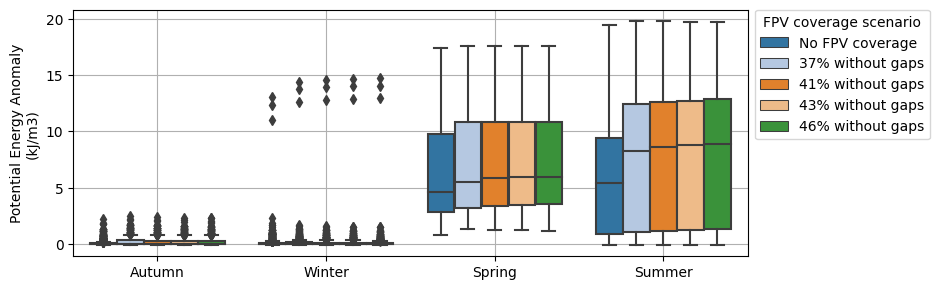

In [29]:
# Plot time series raw data for WT among scenarios
fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize = [9.5,3], sharex = True, sharey = True)
pal = sns.color_palette("tab20", 10)

# my_order = ['41% FPV - 80x80m', '41% FPV - 10x10m', '41% FPV - 10x20m', '41% FPV - 20x20m']

plot = bp_PEA_wholelake_comp[(bp_PEA_wholelake_comp['scenario'] == 'No FPV coverage') |
                             (bp_PEA_wholelake_comp['scenario'] == '37% without gaps') | 
                             (bp_PEA_wholelake_comp['scenario'] == '41% without gaps') | 
                             (bp_PEA_wholelake_comp['scenario'] == '43% without gaps') | 
                             (bp_PEA_wholelake_comp['scenario'] == '46% without gaps')]

my_order = ['No FPV coverage', '37% without gaps', '41% without gaps', '43% without gaps', '46% without gaps']

sns.boxplot(x = "season", y = "PEA", 
            data = bp_PEA_wholelake_comp,
            width = 0.8, boxprops = {'zorder': 2}, palette = pal[0:8], ax = ax, 
            order = ['autumn', 'winter', 'spring', 'summer'],
            hue = 'scenario', hue_order = my_order)

ax.grid(True)

# ax.legend(title = "FPV coverage scenario", ncol = 1, fontsize = 10, 
#                frameon = True, columnspacing = 1)

ax.legend(title = "FPV coverage scenario", ncol = 1, fontsize = 10, 
               frameon = True, columnspacing = 1, bbox_to_anchor=(1, 1.03))

ax.yaxis.set_label_text(u'Potential Energy Anomaly\n(kJ/m3)', fontsize = 10)
ax.xaxis.set_label_text(u'', fontsize = 10)

ax.set_xticklabels(['Autumn', 'Winter', 'Spring', 'Summer'], fontsize=10)

ax.yaxis.set_major_formatter(mpl.ticker.StrMethodFormatter('{x:,.0f}'))

plt.subplots_adjust(wspace = 0, hspace = 0)

plt.tight_layout() # Para ajustar melhor os gráficos
plt.rcdefaults()
# plt.savefig(path_figures + 'FPV01_wholelake_PEA_boxplot_seasonal.jpeg', dpi=600, bbox_inches='tight')

plt.show();

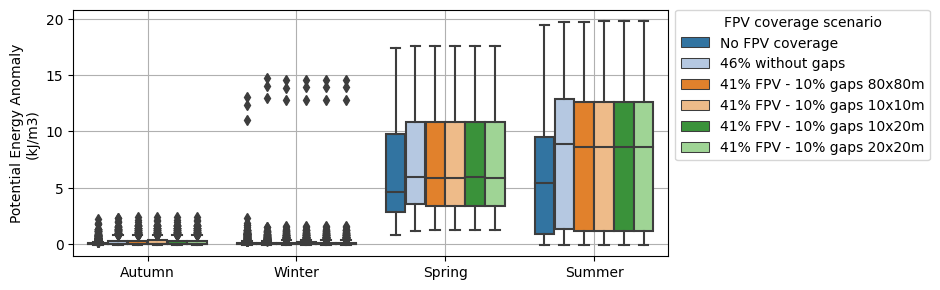

In [24]:
# Plot time series raw data for WT among scenarios
fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize = [9.5,3], sharex = True, sharey = True)
pal = sns.color_palette("tab20", 10)

# my_order = ['41% FPV - 80x80m', '41% FPV - 10x10m', '41% FPV - 10x20m', '41% FPV - 20x20m']

plot = bp_PEA_wholelake_comp[(bp_PEA_wholelake_comp['scenario'] == 'No FPV coverage') |
                             (bp_PEA_wholelake_comp['scenario'] == '41% without gaps') | 
                             (bp_PEA_wholelake_comp['scenario'] == '41% FPV - 10% gaps 80x80m') | 
                             (bp_PEA_wholelake_comp['scenario'] == '41% FPV - 10% gaps 10x10m') | 
                             (bp_PEA_wholelake_comp['scenario'] == '41% FPV - 10% gaps 10x20m') | 
                             (bp_PEA_wholelake_comp['scenario'] == '41% FPV - 10% gaps 10x20m')]

my_order = ['No FPV coverage', '46% without gaps', '41% FPV - 10% gaps 80x80m', '41% FPV - 10% gaps 10x10m', 
            '41% FPV - 10% gaps 10x20m', '41% FPV - 10% gaps 20x20m']

# my_order = ['46% without gaps', '43% without gaps', '41% without gaps', '37% without gaps', 
#             '43% FPV - 5% gaps 10x10m', '41% FPV - 10% gaps 10x10m', '37% FPV - 20% gaps 10x10m', 
#             '41% FPV - 10% gaps 10x10m', '41% FPV - 10% gaps 10x20m', '41% FPV - 10% gaps 20x20m', 
#             '41% FPV - 10% gaps 80x80m', 'No FPV coverage']

sns.boxplot(x = "season", y = "PEA", 
            data = bp_PEA_wholelake_comp,
            width = 0.8, boxprops = {'zorder': 2}, palette = pal[0:8], ax = ax, 
            order = ['autumn', 'winter', 'spring', 'summer'],
            hue = 'scenario', hue_order = my_order)

ax.grid(True)

# ax.legend(title = "FPV coverage scenario", ncol = 1, fontsize = 10, 
#                frameon = True, columnspacing = 1)

ax.legend(title = "FPV coverage scenario", ncol = 1, fontsize = 10, 
               frameon = True, columnspacing = 1, bbox_to_anchor=(1, 1.03))

ax.yaxis.set_label_text(u'Potential Energy Anomaly\n(kJ/m3)', fontsize = 10)
ax.xaxis.set_label_text(u'', fontsize = 10)

ax.set_xticklabels(['Autumn', 'Winter', 'Spring', 'Summer'], fontsize=10)

ax.yaxis.set_major_formatter(mpl.ticker.StrMethodFormatter('{x:,.0f}'))

plt.subplots_adjust(wspace = 0, hspace = 0)

plt.tight_layout() # Para ajustar melhor os gráficos
plt.rcdefaults()
# plt.savefig(path_figures + 'FPV03_wholelake_PEA_boxplot_seasonal.jpeg', dpi=600, bbox_inches='tight')

plt.show();

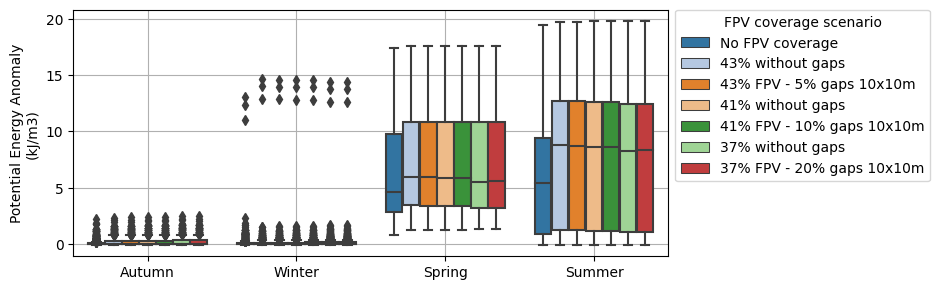

In [26]:
# Plot time series raw data for WT among scenarios
fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize = [9.5,3], sharex = True, sharey = True)
pal = sns.color_palette("tab20", 10)

# my_order = ['41% FPV - 80x80m', '41% FPV - 10x10m', '41% FPV - 10x20m', '41% FPV - 20x20m']

plot = bp_PEA_wholelake_comp[(bp_PEA_wholelake_comp['scenario'] == 'No FPV coverage') |
                             (bp_PEA_wholelake_comp['scenario'] == '43% without gaps') | 
                             (bp_PEA_wholelake_comp['scenario'] == '43% FPV - 5% gaps 10x10m') | 
                             (bp_PEA_wholelake_comp['scenario'] == '41% without gaps') | 
                             (bp_PEA_wholelake_comp['scenario'] == '41% FPV - 10% gaps 10x10m') | 
                             (bp_PEA_wholelake_comp['scenario'] == '37% without gaps') | 
                             (bp_PEA_wholelake_comp['scenario'] == '37% FPV - 20% gaps 10x10m')]

my_order = ['No FPV coverage', '43% without gaps', '43% FPV - 5% gaps 10x10m', '41% without gaps', '41% FPV - 10% gaps 10x10m', 
            '37% without gaps', '37% FPV - 20% gaps 10x10m']

# my_order = ['46% without gaps', '43% without gaps', '41% without gaps', '37% without gaps', 
#             '43% FPV - 5% gaps 10x10m', '41% FPV - 10% gaps 10x10m', '37% FPV - 20% gaps 10x10m', 
#             '41% FPV - 10% gaps 10x10m', '41% FPV - 10% gaps 10x20m', '41% FPV - 10% gaps 20x20m', 
#             '41% FPV - 10% gaps 80x80m', 'No FPV coverage']

sns.boxplot(x = "season", y = "PEA", 
            data = bp_PEA_wholelake_comp,
            width = 0.8, boxprops = {'zorder': 2}, palette = pal[0:8], ax = ax, 
            order = ['autumn', 'winter', 'spring', 'summer'],
            hue = 'scenario', hue_order = my_order)

ax.grid(True)

# ax.legend(title = "FPV coverage scenario", ncol = 1, fontsize = 10, 
#                frameon = True, columnspacing = 1)

ax.legend(title = "FPV coverage scenario", ncol = 1, fontsize = 10, 
               frameon = True, columnspacing = 1, bbox_to_anchor=(1, 1.03))

ax.yaxis.set_label_text(u'Potential Energy Anomaly\n(kJ/m3)', fontsize = 10)
ax.xaxis.set_label_text(u'', fontsize = 10)

ax.set_xticklabels(['Autumn', 'Winter', 'Spring', 'Summer'], fontsize=10)

ax.yaxis.set_major_formatter(mpl.ticker.StrMethodFormatter('{x:,.0f}'))

plt.subplots_adjust(wspace = 0, hspace = 0)

plt.tight_layout() # Para ajustar melhor os gráficos
plt.rcdefaults()
# plt.savefig(path_figures + 'FPV02_wholelake_PEA_boxplot_seasonal.jpeg', dpi=600, bbox_inches='tight')

plt.show();